# State-Space Representation

**Learning Goals**
- Understand what the state of a system is
- Understand the standard state-space form: $\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u}$, $\mathbf{y} = C\mathbf{x} + D\mathbf{u}$
- Convert a differential equation into state-space form
- Understand how the $A$ matrix eigenvalues determine system dynamics
- Simulate a state-space system and visualize the state trajectories
- See how state feedback can move poles to desired locations

## Relevant lecture video

In [1]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/cadd04f5-f542-4ea3-b7ed-c5db10fc8a55/public?autoplay=false&automute=false&currentMediaId=6da341da-a283-4c74-a940-305d15797e1a&sessionId=b2fb7f66-3f3a-498f-85b3-9e2bdcc53d44" frameborder="0" allowfullscreen></iframe>')

/home/matvei/JupyterBasedControlEngineeringTextbook/venv/lib/python3.12/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## What is state-space representation?

In control engineering, a system can be described by its **state**, which is the smallest set of variables that fully captures the system's past so that its future can be predicted given the inputs.

The **state-space form** is a set of first-order differential equations:

$$
\begin{aligned}
\dot{\mathbf{x}} &= A \mathbf{x} + B \mathbf{u} \\
\mathbf{y} &= C \mathbf{x} + D \mathbf{u}
\end{aligned}
$$

| Symbol | Name | Dimension |
|--------|------|-----------|
| $\mathbf{x}$ | State vector | $n \times 1$ |
| $\mathbf{u}$ | Input vector | $m \times 1$ |
| $\mathbf{y}$ | Output vector | $p \times 1$ |
| $A$ | State (system) matrix | $n \times n$ |
| $B$ | Input matrix | $n \times m$ |
| $C$ | Output matrix | $p \times n$ |
| $D$ | Feedthrough matrix | $p \times m$ |

The key insight: an $n$-th order differential equation becomes $n$ coupled first-order equations.

---

## Block on ice in state-space form

Recall the block-on-ice system from the introduction. Newton's second law gives:

$$m \ddot x = F - b \dot x$$

We choose the state vector to contain position and velocity:

$$
\mathbf{x} = \begin{bmatrix} x \\ \dot x \end{bmatrix}
= \begin{bmatrix} x \\ v \end{bmatrix}
$$

The first-order equations are:

$$
\begin{aligned}
\dot x &= v \\
\dot v &= -\frac{b}{m} v + \frac{1}{m} F
\end{aligned}
$$

Writing in matrix form, with position as the measured output:

$$
\dot{\mathbf{x}} = \underbrace{\begin{bmatrix} 0 & 1 \\ 0 & -b/m \end{bmatrix}}_{A}
\mathbf{x} + \underbrace{\begin{bmatrix} 0 \\ 1/m \end{bmatrix}}_{B} F, \qquad
y = \underbrace{\begin{bmatrix} 1 & 0 \end{bmatrix}}_{C} \mathbf{x} + \underbrace{\begin{bmatrix} 0 \end{bmatrix}}_{D} F
$$

With our usual values $m = 10$ kg and $b = 0.5$ N·s/m:

$$
A = \begin{bmatrix} 0 & 1 \\ 0 & -0.05 \end{bmatrix}, \qquad
B = \begin{bmatrix} 0 \\ 0.1 \end{bmatrix}, \qquad
C = \begin{bmatrix} 1 & 0 \end{bmatrix}, \qquad
D = 0
$$

In [1]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle, FancyArrowPatch
from scipy.integrate import solve_ivp
from scipy.signal import lti
from IPython.display import HTML, display, clear_output
import ipywidgets as widgets

# Block diagram drawing helpers
class Summer:
    def __init__(self, x, y, r=0.18, top=None, bottom=None, left=None):
        self.x = x; self.y = y; self.r = r
        self.top_sym = top; self.bottom_sym = bottom; self.left_sym = left
    @property
    def entry_left(self):   return (self.x - self.r, self.y)
    @property
    def entry_top(self):    return (self.x, self.y + self.r)
    @property
    def entry_bottom(self): return (self.x, self.y - self.r)
    @property
    def exit(self):         return (self.x + self.r, self.y)

class Block:
    def __init__(self, x, y, label, w=0.8, h=0.4, facecolor='lightblue'):
        self.x = x; self.y = y; self.label = label
        self.w = w; self.h = h; self.fc = facecolor
    @property
    def left(self):    return self.x - self.w / 2
    @property
    def right(self):   return self.x + self.w / 2
    @property
    def top(self):     return self.y + self.h / 2
    @property
    def bottom(self):  return self.y - self.h / 2
    @property
    def center_left(self):   return (self.left, self.y)
    @property
    def center_right(self):  return (self.right, self.y)
    @property
    def center_top(self):    return (self.x, self.top)
    @property
    def center_bottom(self): return (self.x, self.bottom)

def draw_block_obj(ax, block):
    xy = (block.left, block.bottom)
    box = FancyBboxPatch(xy, block.w, block.h, boxstyle='round,pad=0.05', facecolor=block.fc, edgecolor='k', lw=1.5)
    ax.add_patch(box)
    ax.text(block.x, block.y, block.label, ha='center', va='center', fontsize=11, fontweight='bold')

def draw_summing_obj(ax, s):
    c = Circle((s.x, s.y), s.r, facecolor='white', edgecolor='k', lw=1.5)
    ax.add_patch(c)
    d = s.r * 0.5
    if s.top_sym is not None:
        ax.text(s.x, s.y + d, s.top_sym, ha='center', va='center', fontsize=7, fontweight='bold')
    if s.bottom_sym is not None:
        ax.text(s.x, s.y - d, s.bottom_sym, ha='center', va='center', fontsize=7, fontweight='bold')
    if s.left_sym is not None:
        ax.text(s.x - d, s.y, s.left_sym, ha='center', va='center', fontsize=7, fontweight='bold')

def draw_connection(ax, p1, p2, label='', style='arc3,rad=0'):
    arrow = FancyArrowPatch(p1, p2, arrowstyle='->', connectionstyle=style, lw=1, color='k')
    ax.add_patch(arrow)
    if label:
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 + 0.1
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=10, style='italic')

def draw_line(ax, pts):
    xs, ys = zip(*pts)
    ax.plot(xs, ys, 'k-', lw=1.5)

def draw_dot(ax, xy):
    ax.plot(*xy, 'ko', ms=4)

def connect_blocks(ax, b1, b2, label='', side1='right', side2='left'):
    p1 = getattr(b1, f'center_{side1}')
    p2 = getattr(b2, f'center_{side2}')
    draw_connection(ax, p1, p2, label)

def setup_axes(ax, xl, yl):
    ax.set(xlim=xl, ylim=yl, aspect='equal')
    ax.axis('off')

print("Libraries loaded.")

Libraries loaded.


### Define the state-space model

In [3]:
mass = 10.0
friction = 0.5

A = np.array([[0, 1],
              [0, -friction / mass]])
B = np.array([[0],
              [1 / mass]])
C = np.array([[1, 0]])
D = np.array([[0]])

sys = lti(A, B, C, D)

print("A matrix:")
print(A)
print(f"\nB matrix:\n{B}")
print(f"\nC matrix:\n{C}")
print(f"\nD matrix:\n{D}")

A matrix:
[[ 0.    1.  ]
 [ 0.   -0.05]]

B matrix:
[[0. ]
 [0.1]]

C matrix:
[[1 0]]

D matrix:
[[0]]


---

## Eigenvalues of $A$ = poles of the system

The **eigenvalues** of the $A$ matrix are exactly the **poles** of the transfer function. They determine the system's natural response.

For the block on ice:

$$
\det(sI - A) = \det\begin{bmatrix} s & -1 \\ 0 & s + b/m \end{bmatrix} = s(s + b/m) = 0
$$

So the eigenvalues are $s_1 = 0$ (a free integrator — the block drifts) and $s_2 = -b/m = -0.05$ (slowly decaying velocity).

The eigenvalue at $s = 0$ tells us the open-loop system does **not** naturally return to a setpoint. It integrates any constant force and keeps moving.

In [4]:
eigs = np.linalg.eigvals(A)
print("Eigenvalues of A (open-loop poles):")
for e in eigs:
    print(f"  s = {e.real:.4f} + {e.imag:.4f}j")

Eigenvalues of A (open-loop poles):
  s = 0.0000 + 0.0000j
  s = -0.0500 + 0.0000j


---

## Step response of the state-space system

Let us simulate the open-loop response to a constant force $F = 10$ N.

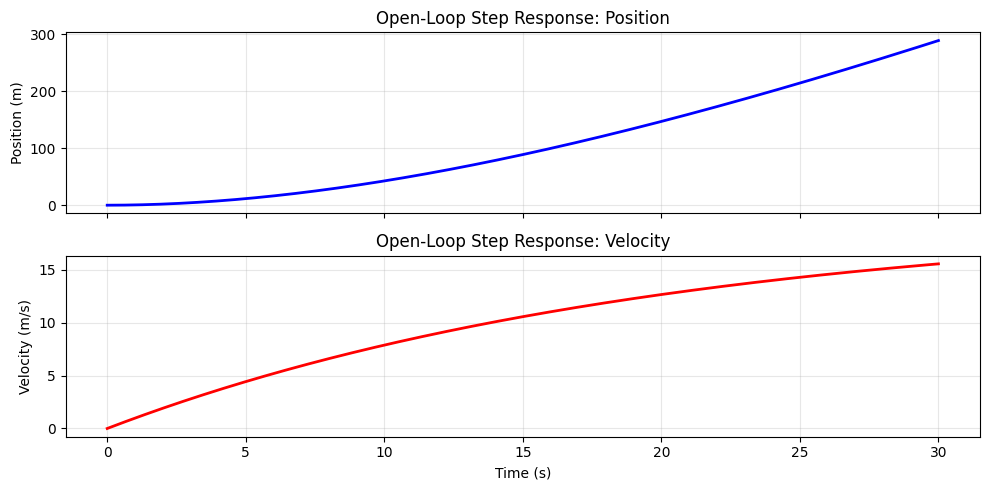

The block accelerates to a terminal velocity where applied force matches friction. Position increases without bound — no setpoint tracking in open loop.


In [5]:
t = np.linspace(0, 30, 3000)
t_out, y_out, x_out = lti(A, B, C, D).output([10.0] * len(t), t, X0=[0, 0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.plot(t, y_out, 'b-', linewidth=2)
ax1.set(ylabel='Position (m)', title='Open-Loop Step Response: Position')
ax1.grid(alpha=0.3)

ax2.plot(t, x_out[:, 1], 'r-', linewidth=2)
ax2.set(xlabel='Time (s)', ylabel='Velocity (m/s)', title='Open-Loop Step Response: Velocity')
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()
print("The block accelerates to a terminal velocity where applied force matches friction."
      " Position increases without bound — no setpoint tracking in open loop.")

---

## Block diagram representation of state-space

The state-space equations can be drawn as a block diagram. This helps visualize the feedback structure inherent in the dynamics:

$$
\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u}, \qquad \mathbf{y} = C\mathbf{x} + D\mathbf{u}
$$

The diagram has two main paths:
- The **state equation** ($\dot{\mathbf{x}}$ integrates to $\mathbf{x}$, then feeds back through $A$)
- The **output equation** ($\mathbf{y}$ combines $\mathbf{x}$ through $C$ and $\mathbf{u}$ through $D$)

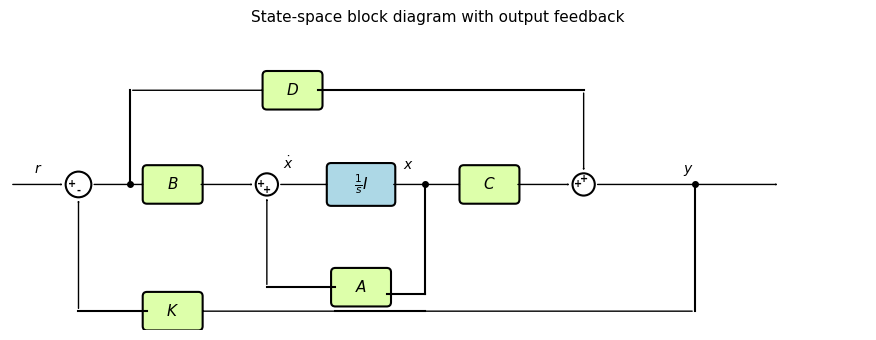

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
setup_axes(ax, (0, 10), (0, 3.5))
ax.set_title('State-space block diagram with output feedback', fontsize=11)
y_m = 1.7
# Forward path
s_in = Summer(0.8, y_m, r=0.15, left='+', bottom='-')
bB = Block(1.9, y_m, '$B$', w=0.6, h=0.35, facecolor='#DDFFAA')
s_xd = Summer(3.0, y_m, r=0.13, left='+', bottom='+')
bInt = Block(4.1, y_m, '$\\frac{1}{s}I$', w=0.7, h=0.4)
bC = Block(5.6, y_m, '$C$', w=0.6, h=0.35, facecolor='#DDFFAA')
s_y = Summer(6.7, y_m, r=0.13, left='+', top='+')
# D above, A and K below
bD = Block(3.3, 2.8, '$D$', w=0.6, h=0.35, facecolor='#DDFFAA')
bA = Block(4.1, 0.5, '$A$', w=0.6, h=0.35, facecolor='#DDFFAA')
bK = Block(1.9, 0.22, '$K$', w=0.6, h=0.35, facecolor='#DDFFAA')
# Draw
draw_summing_obj(ax, s_in)
draw_block_obj(ax, bB); draw_summing_obj(ax, s_xd); draw_block_obj(ax, bInt)
draw_block_obj(ax, bC); draw_summing_obj(ax, s_y)
draw_block_obj(ax, bD); draw_block_obj(ax, bA); draw_block_obj(ax, bK)
# r → s_in
draw_connection(ax, (0, y_m), s_in.entry_left, 'r')
# s_in → B (with tee up to D)
draw_connection(ax, s_in.exit, bB.center_left)
draw_dot(ax, (1.4, y_m))
draw_line(ax, [(1.4, y_m), (1.4, bD.center_left[1])])
draw_connection(ax, (1.4, bD.center_left[1]), bD.center_left)
# B → s_xd
draw_connection(ax, bB.center_right, s_xd.entry_left)
# s_xd → ∫  with ẋ label
draw_connection(ax, s_xd.exit, bInt.center_left)
ax.text(s_xd.x + s_xd.r + 0.12, y_m + 0.15, '$\\dot{x}$',
         ha='center', va='bottom', fontsize=10, style='italic')
# ∫ → C (with tee down to A)
draw_connection(ax, bInt.center_right, bC.center_left)
draw_dot(ax, (4.85, y_m))
ax.text((bInt.x + bInt.w / 2 + 4.85) / 2, y_m + 0.15, '$x$',
         ha='center', va='bottom', fontsize=10, style='italic')
draw_line(ax, [(4.85, y_m), (4.85, bA.bottom+0.1)])
draw_line(ax, [(4.85, bA.bottom+0.1), (bA.right, bA.bottom+0.1)])
draw_line(ax, [(4.85, bA.bottom - 0.1), (bA.left, bA.bottom - 0.1)])
# A → s_xd
draw_line(ax, [bA.center_left, (s_xd.x, bA.y)])
draw_connection(ax, (s_xd.x, bA.y), s_xd.entry_bottom)
# C → s_y
draw_connection(ax, bC.center_right, s_y.entry_left)
# D → s_y (right then down)
draw_line(ax, [bD.center_right, (s_y.x, bD.center_right[1])])
draw_connection(ax, (s_y.x, bD.center_right[1]), s_y.entry_top)
# s_y → y (with tee down to K)
draw_connection(ax, s_y.exit, (9.0, y_m), 'y')
draw_dot(ax, (8.0, y_m))
draw_line(ax, [(8.0, y_m), (8.0, bK.center_left[1])])
draw_connection(ax, (8.0, bK.center_left[1]), bK.center_right)
# K → s_in (left then up)
draw_line(ax, [bK.center_left, (s_in.x, bK.y)])
draw_connection(ax, (s_in.x, bK.y), s_in.entry_bottom)
fig.tight_layout()
plt.show()

### From state-space to transfer function

Taking the Laplace transform of the state equation:

$$s\mathbf{X}(s) - \mathbf{x}(0) = A\mathbf{X}(s) + B\mathbf{U}(s)$$

Assuming zero initial conditions and solving for $\mathbf{X}(s)$:

$$\mathbf{X}(s) = (sI - A)^{-1} B \, \mathbf{U}(s)$$

Substituting into $\mathbf{Y}(s) = C\mathbf{X}(s) + D\mathbf{U}(s)$:

$$\mathbf{Y}(s) = \bigl[C(sI - A)^{-1}B + D\bigr] \, \mathbf{U}(s)$$

So the transfer function matrix is:

$$G(s) = C(sI - A)^{-1}B + D$$

For the block on ice ($m = 10$, $b = 0.5$):

$$
G(s) = \begin{bmatrix}1 & 0\end{bmatrix}
\begin{bmatrix}s & -1 \\ 0 & s + 0.05\end{bmatrix}^{-1}
\begin{bmatrix}0 \\ 0.1\end{bmatrix}
= \frac{0.1}{s(s + 0.05)} = \frac{1}{10s^2 + 0.5s}
$$

which matches our transfer function from $F$ to $x$.

---

## Case study 1: Block on frictionless surface

Consider a block of mass $m$ on a perfectly smooth surface (no friction). A force $F$ is applied:

$$m \ddot x = F \quad\Longrightarrow\quad \ddot x = \frac{F}{m}$$

### Laplace-domain solution

Taking the Laplace transform (zero initial conditions):

$$m s^2 X(s) = F(s) \quad\Longrightarrow\quad G(s) = \frac{X(s)}{F(s)} = \frac{1}{m s^2}$$

This is a **double integrator** — two poles at $s = 0$.

### State-space solution

Choose $\mathbf{x} = [x, \dot x]^T$:

$$
\dot{\mathbf{x}} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix} \mathbf{x}
+ \begin{bmatrix} 0 \\ 1/m \end{bmatrix} F, \qquad
y = \begin{bmatrix} 1 & 0 \end{bmatrix} \mathbf{x}
$$

Both poles are at $s = 0$ — the system is marginally stable (a constant force produces unbounded motion).

In [7]:
def frictionless_surface(m=5.0, F=10.0):
    A_fs = np.array([[0, 1], [0, 0]])
    B_fs = np.array([[0], [1 / m]])
    C_fs = np.array([[1, 0]])
    t = np.linspace(0, 10, 1000)
    def fs_dynamics(t, x):
        return A_fs @ x + B_fs.flatten() * F
    x_out = solve_ivp(fs_dynamics, [0, 10], [0, 0], t_eval=t,
                      method='RK45').y.T
    y_out = C_fs @ x_out.T
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(t, y_out.flatten(), 'b-', lw=2)
    ax1.set(xlabel='Time (s)', ylabel='Position (m)',
            title=f'Frictionless surface ($m$ = {m} kg)')
    ax1.grid(alpha=0.3)
    ax2.plot(t, x_out[:, 1], 'r-', lw=2)
    ax2.set(xlabel='Time (s)', ylabel='Velocity (m/s)',
            title='Velocity (linear growth)')
    ax2.grid(alpha=0.3)
    fig.tight_layout(); plt.show()
    print(f"Transfer function: G(s) = 1/({m}s^2)")
    print("Two poles at s = 0 (double integrator).")
    print("With no friction, velocity grows linearly and position grows quadratically.")

fs_m = widgets.FloatSlider(min=1, max=20, step=0.5, value=5,
                           description='Mass $m$ (kg):',
                           style={'description_width': 'initial'})
fs_btn = widgets.Button(description='Simulate', button_style='primary')
fs_out = widgets.Output()

def on_fs(b):
    with fs_out:
        clear_output(wait=True)
        frictionless_surface(fs_m.value)
fs_btn.on_click(on_fs)
display(widgets.VBox([fs_m, fs_btn, fs_out]))
print("Adjust the mass and click Simulate.")

Adjust the mass and click Simulate.


---

## Case study 2: Block on a spring (mass-spring system)

Now add a spring (stiffness $k$) and friction ($b$) to the block:

$$m \ddot x + b \dot x + k x = F$$

### Laplace-domain solution

$$G(s) = \frac{X(s)}{F(s)} = \frac{1}{m s^2 + b s + k}$$

The poles are $s = \frac{-b \pm \sqrt{b^2 - 4mk}}{2m}$.

### State-space solution

Choose $\mathbf{x} = [x, \dot x]^T$:

$$
\dot{\mathbf{x}} = \begin{bmatrix} 0 & 1 \\ -k/m & -b/m \end{bmatrix} \mathbf{x}
+ \begin{bmatrix} 0 \\ 1/m \end{bmatrix} F, \qquad
y = \begin{bmatrix} 1 & 0 \end{bmatrix} \mathbf{x}
$$

In [8]:
def mass_spring_damper(m=5.0, b=2.0, k=10.0, F=10.0):
    A_ms = np.array([[0, 1], [-k / m, -b / m]])
    B_ms = np.array([[0], [1 / m]])
    C_ms = np.array([[1, 0]])
    D_ms = np.array([[0]])
    from scipy.signal import lti
    sys = lti(A_ms, B_ms, C_ms, D_ms)
    t = np.linspace(0, 20, 2000)
    t_out, y_out, x_out = sys.output([F] * len(t), t, X0=[0, 0])
    eigs = np.linalg.eigvals(A_ms)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(t, y_out, 'b-', lw=2)
    ax1.axhline(F / k, color='k', ls='--', alpha=0.4,
                label=f'Steady-state = {F/k:.2f} m')
    ax1.set(xlabel='Time (s)', ylabel='Position (m)',
            title=f'Mass-spring-damper ($m$={m}, $b$={b}, $k$={k})')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
    ax2.plot(t, x_out[:, 1], 'r-', lw=2)
    ax2.set(xlabel='Time (s)', ylabel='Velocity (m/s)', title='Velocity')
    ax2.grid(alpha=0.3)
    fig.tight_layout(); plt.show()
    pole_str = ', '.join([f'{e:.3f}' for e in eigs])
    print(f"Poles: {pole_str}")
    print(f"Steady-state position (F/k): {F/k:.2f} m")
    if all(e.real < 0 for e in eigs):
        print("System is stable (all poles in LHP).")
    else:
        print("System is unstable or marginally stable.")

ms_m = widgets.FloatSlider(min=1, max=20, step=0.5, value=5,
                           description='Mass $m$ (kg):',
                           style={'description_width': 'initial'})
ms_b = widgets.FloatSlider(min=0, max=20, step=0.5, value=2,
                           description='Damping $b$ (N·s/m):',
                           style={'description_width': 'initial'})
ms_k = widgets.FloatSlider(min=1, max=30, step=0.5, value=10,
                           description='Stiffness $k$ (N/m):',
                           style={'description_width': 'initial'})
ms_btn = widgets.Button(description='Simulate', button_style='primary')
ms_out = widgets.Output()

def on_ms(b):
    with ms_out:
        clear_output(wait=True)
        mass_spring_damper(ms_m.value, ms_b.value, ms_k.value)
ms_btn.on_click(on_ms)
display(widgets.VBox([ms_m, ms_b, ms_k, ms_btn, ms_out]))
print("Adjust parameters and click Simulate.")

Adjust parameters and click Simulate.


---

## Closed-loop state feedback (pole placement)

In state-space control, we can design a **state feedback** law:

$$F = -K \mathbf{x} + r$$

where $K = [k_1, k_2]$ is the gain vector and $r$ is the reference. Substituting into the state equation:

$$
\dot{\mathbf{x}} = (A - BK)\mathbf{x} + B r
$$

The closed-loop dynamics depend on the eigenvalues of $A - BK$. By choosing $K$, we can place the closed-loop poles anywhere (if the system is controllable).

Below we apply this to the **block-on-ice** model ($m = 10$ kg, $b = 0.5$ N·s/m) defined earlier. Adjust the gains and see how the closed-loop poles and step response change.

In [9]:
def simulate_state_feedback(K, setpoint=10.0, t_span=30.0):
    A_cl = A - B @ K.reshape((1, 2))
    eigs_cl = np.linalg.eigvals(A_cl)

    def ode(t, state):
        x, v = state
        F = -K[0] * (x - setpoint) - K[1] * v
        friction_force = -friction * v
        dxdt = v
        dvdt = (F + friction_force) / mass
        return [dxdt, dvdt]

    t_eval = np.linspace(0, t_span, 600)
    sol = solve_ivp(ode, [0, t_span], [0.0, 0.0], t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1], eigs_cl

def closed_loop_response(K1=1.0, K2=5.0):
    K = np.array([K1, K2])
    t, x, v, eigs_cl = simulate_state_feedback(K)

    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[:, 0])
    s_min = max(-3, min(np.real(eigs_cl)) - 0.5)
    s_max = max(0.5, max(np.imag(eigs_cl)) + 0.5)
    limit = max(abs(s_min), s_max, 1.0) * 1.2
    ax1.axhline(0, color='k', linewidth=0.8)
    ax1.axvline(0, color='k', linewidth=0.8)
    ax1.set_xlim(-limit, limit)
    ax1.set_ylim(-limit, limit)
    ax1.set(xlabel='Re($s$)', ylabel='Im($s$)', title='Closed-Loop Pole Locations')
    ax1.grid(alpha=0.3)
    for e in eigs_cl:
        ax1.plot(e.real, e.imag, 'rx', markersize=12, markeredgewidth=3)
    ax1.axvspan(-limit, 0, alpha=0.06, color='g')
    ax1.axvspan(0, limit, alpha=0.06, color='r')
    ax1.axis('equal')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t, x, 'b-', linewidth=2)
    ax2.axhline(10, color='k', ls='--', alpha=0.4, label='Setpoint = 10 m')
    ax2.set(ylabel='Position (m)', title='Time Response')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(t, v, 'r-', linewidth=2)
    ax3.axhline(0, color='k', alpha=0.3)
    ax3.set(xlabel='Time (s)', ylabel='Velocity (m/s)', title='Velocity')
    ax3.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    eig_str = ', '.join([f'{e:.3f}' for e in eigs_cl])
    print(f'Closed-loop poles: {eig_str}')

K1_slider = widgets.FloatSlider(min=0.0, max=10.0, step=0.1, value=1.0,
                                description='$k_1$ (position gain):',
                                style={'description_width': 'initial'})
K2_slider = widgets.FloatSlider(min=0.0, max=20.0, step=0.1, value=5.0,
                                description='$k_2$ (velocity gain):',
                                style={'description_width': 'initial'})
run_btn = widgets.Button(description='Run', button_style='primary')
out = widgets.Output()

def on_run(b):
    with out:
        clear_output(wait=True)
        closed_loop_response(K1_slider.value, K2_slider.value)

run_btn.on_click(on_run)
display(widgets.VBox([K1_slider, K2_slider, run_btn, out]))

print("Adjust the gains, then click Run to place poles and see the response.")

Adjust the gains, then click Run to place poles and see the response.


**Observation.**
- $k_1$ (position gain) controls the restoring force — higher $k_1$ pulls the block to the setpoint faster.
- $k_2$ (velocity gain) provides damping — higher $k_2$ reduces overshoot.
- The closed-loop poles move as we adjust gains. As long as all poles are in the left half-plane, the system is stable.
- Notice that with $k_1 > 0$ and $k_2 > 0$, the eigenvalue at $s = 0$ (the integrator) moves into the left half-plane.

---

## Summary

- **State-space representation** models a system using $\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u}$, $\mathbf{y} = C\mathbf{x} + D\mathbf{u}$.
- The **state vector** $\mathbf{x}$ contains the minimum variables needed to predict future behavior.
- **Eigenvalues of $A$** are the system poles. They determine stability and response shape.
- The block diagram of a state-space system has an inherent feedback loop through the $A$ matrix.
- Transfer function from state-space: $G(s) = C(sI - A)^{-1}B + D$.
- **Frictionless surface:** $G(s) = 1/(ms^2)$ — double integrator, two poles at $s=0$.
- **Mass-spring-damper:** $G(s) = 1/(ms^2 + bs + k)$ — poles depend on $m$, $b$, $k$.